<a href="https://colab.research.google.com/github/Siuuuuuu0/ML-DL/blob/main/Trades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Монте Карло

In [23]:
!pip install fastparquet

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
PATH = '/content/drive/MyDrive/Colab Notebooks/trades.parquet'

In [26]:
df = pd.read_parquet(PATH, engine="fastparquet")

In [27]:
df.head()

,TIME,SIDE,TRADE,VOLUME,log_date
0,36000007212,0,11.663,1000,2025-04-01
1,36000007212,0,11.663,19000,2025-04-01
2,36000007212,0,11.663,1000,2025-04-01
3,36000007212,0,11.663,50000,2025-04-01
4,36000007212,0,11.663,1000,2025-04-01


In [28]:
STEP = "1S"
SEED = 52
dt_seconds = pd.to_timedelta(STEP).total_seconds()
SIM_DURATION_SECONDS = 15 * 60
SIM_STEPS = int(SIM_DURATION_SECONDS / dt_seconds)
N_PATHS = 10

/tmp/ipython-input-586/2212391682.py:3: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  dt_seconds = pd.to_timedelta(STEP).total_seconds()


In [29]:
df["log_date"] = pd.to_datetime(df["log_date"])
df["ts"] = df["log_date"] + pd.to_timedelta(df["TIME"], unit="us")
df = df.sort_values("ts").set_index("ts")

In [30]:
df.head()

,TIME,SIDE,TRADE,VOLUME,log_date
ts,,,,,
2025-04-01 10:00:00.007212,36000007212,0,11.663,1000,2025-04-01
2025-04-01 10:00:00.007212,36000007212,0,11.663,57000,2025-04-01
2025-04-01 10:00:00.007212,36000007212,0,11.663,50000,2025-04-01
2025-04-01 10:00:00.007212,36000007212,0,11.663,100000,2025-04-01
2025-04-01 10:00:00.007212,36000007212,0,11.663,50000,2025-04-01


Text(0.5, 1.0, 'Price changes')

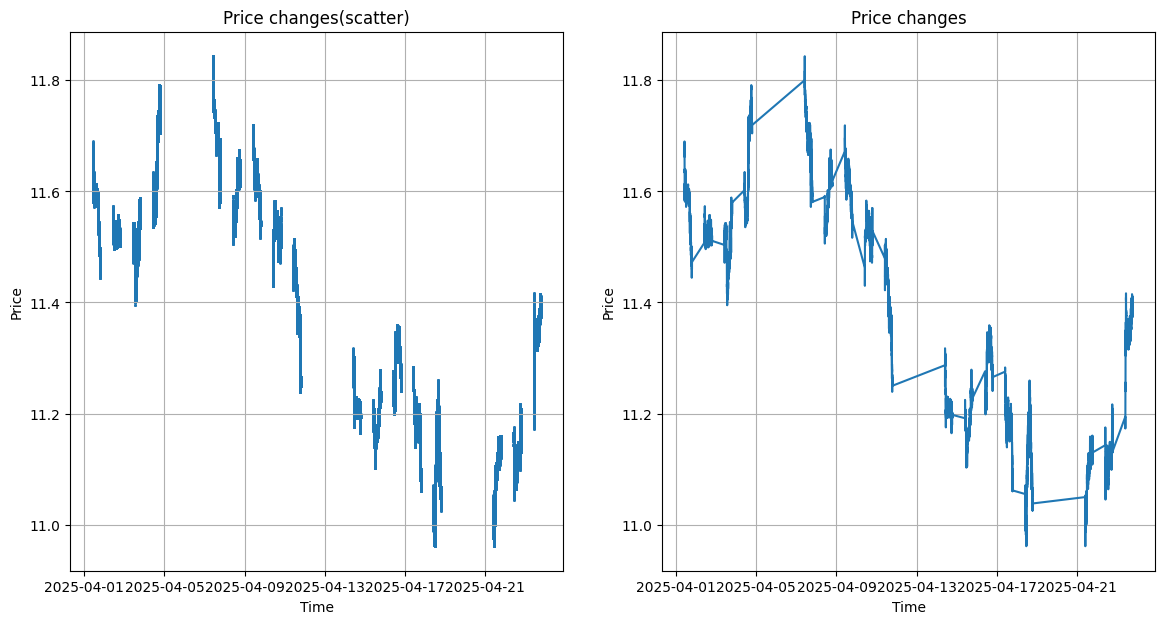

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

ax[0].scatter(df.index, df["TRADE"], s=1)
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Price")
ax[0].set_title("Price changes(scatter)")
ax[0].grid(True)


ax[1].plot(df.index, df["TRADE"])
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Price")
ax[1].grid(True)
ax[1].set_title("Price changes")

In [33]:
dt = df.index.to_series().diff()
dt.quantile([0.5, 0.9, 0.99, 0.999, 0.99999999])

,ts
0.500,0 days 00:00:00.002673
0.900,0 days 00:00:01.100694
0.990,0 days 00:00:05.119183880
0.999,0 days 00:00:15.165104588
1.000,2 days 15:00:03.930382985


In [34]:
# решить проблему промежутков иначе сильно низкая волатильность(сигма)(дни без активности), но не убирать полностью, иначе как будто времени не прошло
# Порог паузы по квантилю

In [35]:
dt_ticks = df.index.to_series().diff().dropna()

q = 0.999
k = 10
m = 5  # минимум 5 шагов сетки считаем дырой

gap_from_dt = dt_ticks.quantile(q) * k
gap_from_step = pd.Timedelta(STEP) * m

GAP = max(gap_from_dt, gap_from_step)
GAP

/tmp/ipython-input-586/3969907573.py:8: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  gap_from_step = pd.Timedelta(STEP) * m


Timedelta('0 days 00:02:31.651045880')

In [36]:
is_gap = (df.index.to_series().diff() > GAP).fillna(False)
is_gap.sum()

np.int64(16)

In [37]:
dt = df.index.to_series().diff()
session_id = (dt > GAP).cumsum()

df2 = df.copy()
df2["session_id"] = session_id.values

g = df2.groupby([df2.index, "session_id"], sort=False)

vwap_ts = (g.apply(lambda x: (x["TRADE"] * x["VOLUME"]).sum()) / g["VOLUME"].sum())
vwap_list = []
for sid, s in vwap_ts.groupby(level=1):
    s = s.droplevel(1)
    s_res = s.resample(STEP).last().ffill()
    vwap_list.append(s_res)

vwap = pd.concat(vwap_list).sort_index()

/tmp/ipython-input-586/1829150265.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_ts = (g.apply(lambda x: (x["TRADE"] * x["VOLUME"]).sum()) / g["VOLUME"].sum())
/tmp/ipython-input-586/1829150265.py:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  s_res = s.resample(STEP).last().ffill()


In [38]:
vwap.head()

,0
ts,
2025-04-01 10:00:00,11.67650
2025-04-01 10:00:01,11.67650
2025-04-01 10:00:02,11.68550
2025-04-01 10:00:03,11.67625
2025-04-01 10:00:04,11.68200


In [39]:
price = vwap
r = np.log(price).diff().dropna()

dSt​=μSt​dt+σSt​dWt​

mu_step: -4.749882456787709e-08 sigma_step: 7.563304347382109e-05 n: 550757


/tmp/ipython-input-586/1037677188.py:18: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  t_index = pd.date_range(start=price.index[-1], periods=SIM_STEPS, freq=STEP)


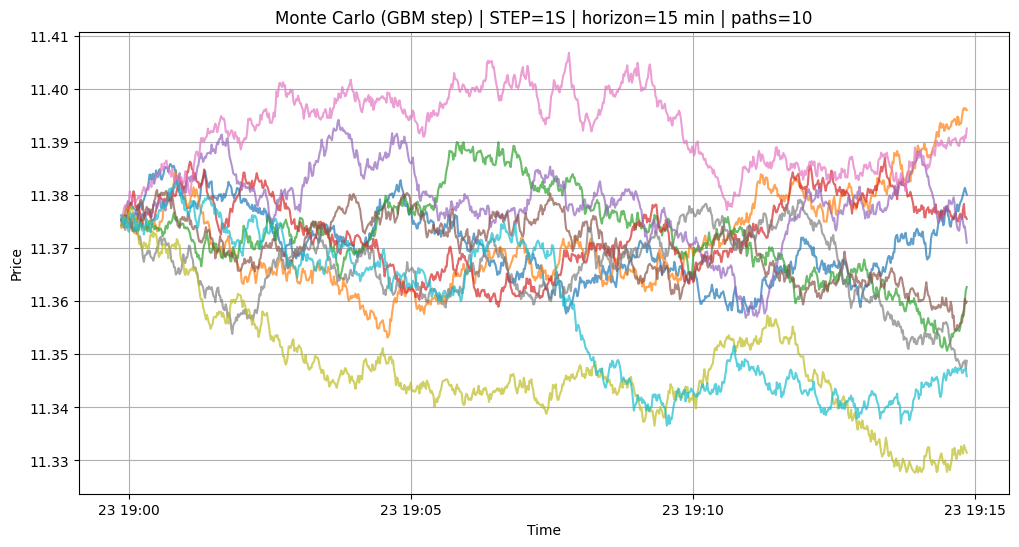

In [40]:
price = vwap.astype(float)
r = np.log(price).diff().dropna()

mu_step = r.mean()
sigma_step = r.std(ddof=1)

print("mu_step:", mu_step, "sigma_step:", sigma_step, "n:", len(r))

np.random.seed(SEED)

S0 = float(price.iloc[-1])
Z = np.random.randn(SIM_STEPS, N_PATHS)
sim_r = mu_step + sigma_step * Z

logS = np.log(S0) + np.cumsum(sim_r, axis=0)
S = np.exp(logS)

t_index = pd.date_range(start=price.index[-1], periods=SIM_STEPS, freq=STEP)
S_df = pd.DataFrame(S, index=t_index)

plt.figure(figsize=(12,6))
plt.plot(S_df.iloc[:, :min(30, N_PATHS)], alpha=0.7)
plt.title(f"Monte Carlo (GBM step) | STEP={STEP} | horizon={SIM_DURATION_SECONDS/60:.0f} min | paths={N_PATHS}")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Trade imbalance

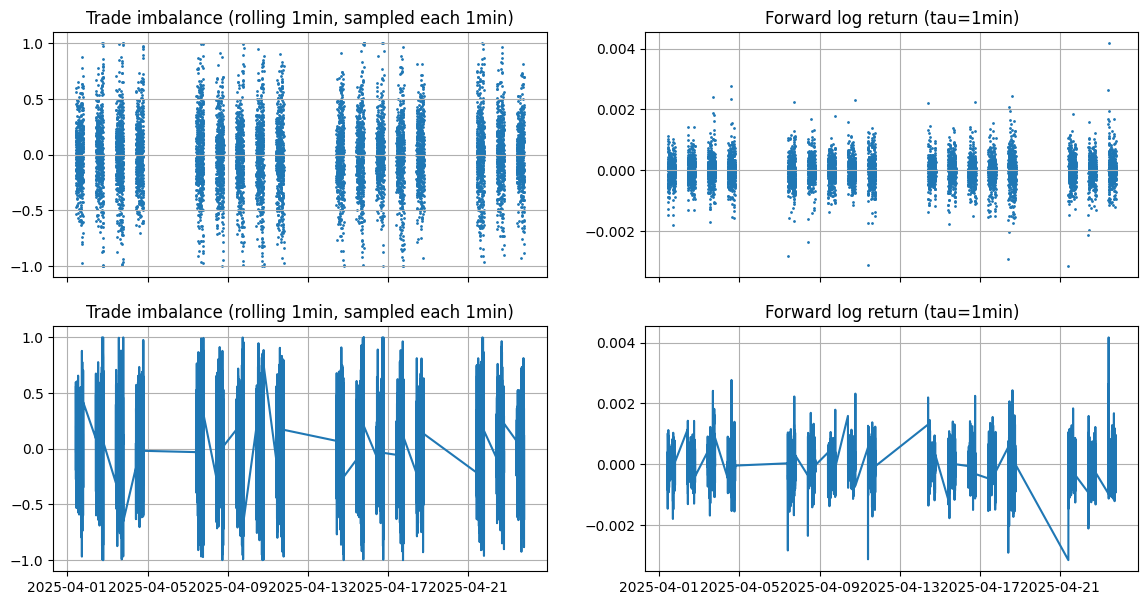

In [46]:
WINDOW = "1min"
TAU = "1min"
GRID = "1min"

buy_flow = df["VOLUME"].where(df["SIDE"] == 0, 0.0)
sell_flow = df["VOLUME"].where(df["SIDE"] == 1, 0.0)

buy_window = buy_flow.rolling(WINDOW).sum()
sell_window = sell_flow.rolling(WINDOW).sum()

t_i_roll = (buy_window - sell_window) / (buy_window + sell_window)
t_i_roll = t_i_roll.replace([np.inf, -np.inf], np.nan)

price_grid = ((df["TRADE"] * df["VOLUME"]).resample(GRID).sum()
              / df["VOLUME"].resample(GRID).sum())

tau_steps = int(pd.Timedelta(TAU) / pd.Timedelta(GRID))
ret_fwd = np.log(price_grid.shift(-tau_steps) / price_grid)

t_i_grid = t_i_roll.resample(GRID).last()

data = pd.DataFrame({
    "trade_imbalance": t_i_grid,
    "return": ret_fwd
}).dropna()

fig, ax = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

ax[0][0].scatter(data.index, data["trade_imbalance"], s=1)
ax[0][0].set_title("Trade imbalance (rolling 1min, sampled each 1min)")
ax[0][0].grid(True)

ax[0][1].scatter(data.index, data["return"], s=1)
ax[0][1].set_title("Forward log return (tau=1min)")
ax[0][1].grid(True)

ax[1][0].plot(data.index, data["trade_imbalance"])
ax[1][0].set_title("Trade imbalance (rolling 1min, sampled each 1min)")
ax[1][0].grid(True)

ax[1][1].plot(data.index, data["return"])
ax[1][1].set_title("Forward log return (tau=1min)")
ax[1][1].grid(True)

plt.show()